# Financial Fraud Detection 






In [2]:
#  Importing all  libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

import joblib




In [3]:
# Load dataset
df = pd.read_csv("synthetic_fraud_dataset1.csv")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()


Rows: 50000
Columns: 14


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Date,Account_Balance,Device_Type,Location,Merchant_Category,Previous_Fraudulent_Activity,Daily_Transaction_Count,Card_Type,Card_Age,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,14 August 2023,93213.17,Laptop,Sydney,Travel,0,7,Amex,65,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,7 June 2023,75725.25,Mobile,New York,Clothing,0,13,Mastercard,186,1
2,TXN_199,USER_2734,28.96,Online,20 June 2023,1588.96,Tablet,Mumbai,Restaurants,0,14,Visa,226,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,7 December 2023,76807.20,Tablet,New York,Clothing,0,8,Visa,76,1
4,TXN_39489,USER_2014,31.28,POS,11 November 2023,92354.66,Mobile,Mumbai,Electronics,1,14,Mastercard,140,1


In [4]:
#  Checking  the data
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Transaction_ID                50000 non-null  object 
 1   User_ID                       50000 non-null  object 
 2   Transaction_Amount            50000 non-null  float64
 3   Transaction_Type              50000 non-null  object 
 4   Date                          50000 non-null  object 
 5   Account_Balance               50000 non-null  float64
 6   Device_Type                   50000 non-null  object 
 7   Location                      50000 non-null  object 
 8   Merchant_Category             50000 non-null  object 
 9   Previous_Fraudulent_Activity  50000 non-null  int64  
 10  Daily_Transaction_Count       50000 non-null  int64  
 11  Card_Type                     50000 non-null  object 
 12  Card_Age                      50000 non-null  int64  
 13  F

In [5]:
#  Checking missing values
print(df.isnull().sum())


Transaction_ID                  0
User_ID                         0
Transaction_Amount              0
Transaction_Type                0
Date                            0
Account_Balance                 0
Device_Type                     0
Location                        0
Merchant_Category               0
Previous_Fraudulent_Activity    0
Daily_Transaction_Count         0
Card_Type                       0
Card_Age                        0
Fraud_Label                     0
dtype: int64


In [6]:
# checking  duplicate rows
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [7]:
# 6. Basic statistics
df.describe()


,Transaction_Amount,Account_Balance,Previous_Fraudulent_Activity,Daily_Transaction_Count,Card_Age,Fraud_Label
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,99.411012,50294.065981,0.098400,7.485240,119.999940,0.321340
std,98.687292,28760.458557,0.297858,4.039637,68.985817,0.466996
min,0.000000,500.480000,0.000000,1.000000,1.000000,0.000000
25%,28.677500,25355.995000,0.000000,4.000000,60.000000,0.000000
50%,69.660000,50384.430000,0.000000,7.000000,120.000000,0.000000
75%,138.852500,75115.135000,0.000000,11.000000,180.000000,1.000000
max,1174.140000,99998.310000,1.000000,14.000000,239.000000,1.000000


Fraud_Label
0    33933
1    16067
Name: count, dtype: int64


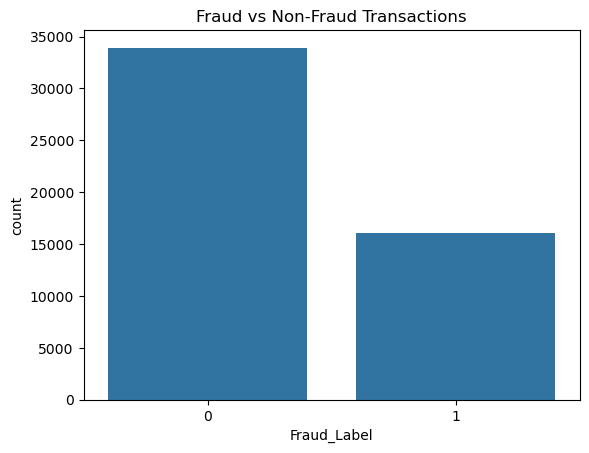

In [8]:
# Checking  fraud and non-fraud transactions
print(df["Fraud_Label"].value_counts())

sns.countplot(data=df, x="Fraud_Label")
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()


In [9]:
#  Convert Date into useful features
df["Date"] = pd.to_datetime(df["Date"])

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek

# 1 = Weekend, 0 = Weekday
df["IsWeekend"] = df["DayOfWeek"].isin([5, 6]).astype(int)

# Date column is no longer needed
df.drop("Date", axis=1, inplace=True)

df.head()


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Account_Balance,Device_Type,Location,Merchant_Category,Previous_Fraudulent_Activity,Daily_Transaction_Count,Card_Type,Card_Age,Fraud_Label,Year,Month,Day,DayOfWeek,IsWeekend
0,TXN_33553,USER_1834,39.79,POS,93213.17,Laptop,Sydney,Travel,0,7,Amex,65,0,2023,8,14,0,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,75725.25,Mobile,New York,Clothing,0,13,Mastercard,186,1,2023,6,7,2,0
2,TXN_199,USER_2734,28.96,Online,1588.96,Tablet,Mumbai,Restaurants,0,14,Visa,226,1,2023,6,20,1,0
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,76807.20,Tablet,New York,Clothing,0,8,Visa,76,1,2023,12,7,3,0
4,TXN_39489,USER_2014,31.28,POS,92354.66,Mobile,Mumbai,Electronics,1,14,Mastercard,140,1,2023,11,11,5,1


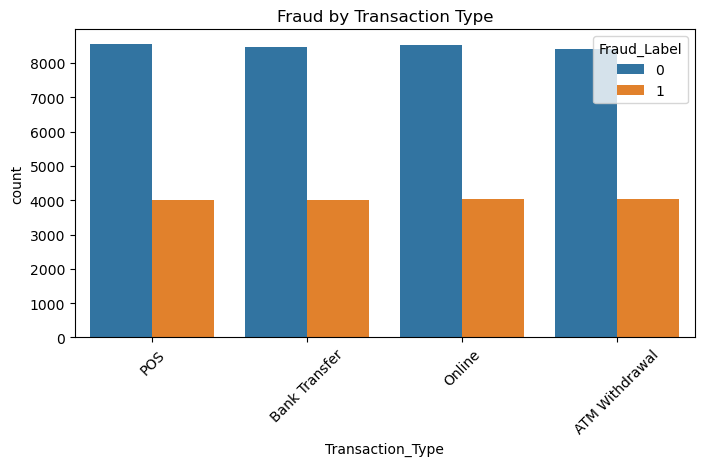

In [10]:
#  Fraud by transaction type
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="Transaction_Type", hue="Fraud_Label")
plt.xticks(rotation=45)
plt.title("Fraud by Transaction Type")
plt.show()


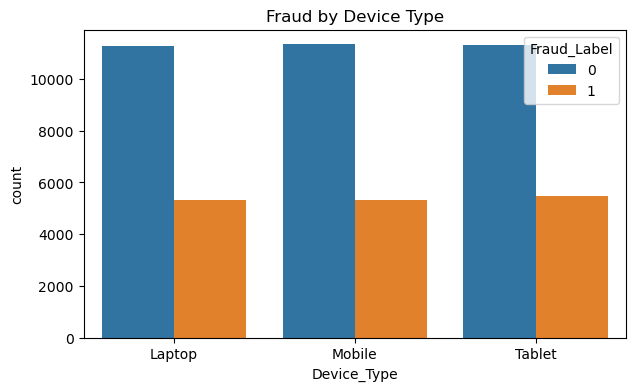

In [11]:
#  Fraud by device
plt.figure(figsize=(7,4))
sns.countplot(data=df, x="Device_Type", hue="Fraud_Label")
plt.title("Fraud by Device Type")
plt.show()


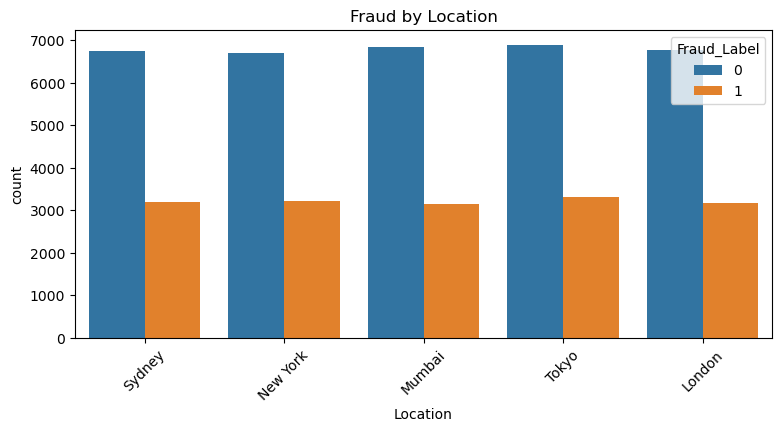

In [12]:
#  Fraud by location
plt.figure(figsize=(9,4))
sns.countplot(data=df, x="Location", hue="Fraud_Label")
plt.xticks(rotation=45)
plt.title("Fraud by Location")
plt.show()


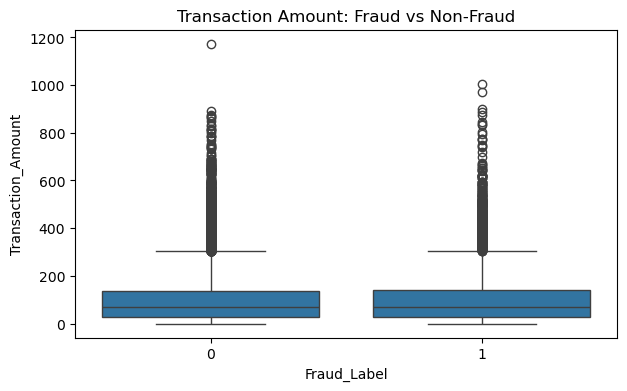

In [13]:
#  Transaction amount comparison
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x="Fraud_Label", y="Transaction_Amount")
plt.title("Transaction Amount: Fraud vs Non-Fraud")
plt.show()


In [14]:
#  Simple feature engineering
df["Amount_Balance_Ratio"] = (
    df["Transaction_Amount"] / (df["Account_Balance"] + 1)
)

df["High_Amount_Flag"] = (
    df["Transaction_Amount"] > df["Transaction_Amount"].median()
).astype(int)

df["High_Transaction_Frequency"] = (
    df["Daily_Transaction_Count"] > df["Daily_Transaction_Count"].median()
).astype(int)

df.head()


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Account_Balance,Device_Type,Location,Merchant_Category,Previous_Fraudulent_Activity,Daily_Transaction_Count,...,Card_Age,Fraud_Label,Year,Month,Day,DayOfWeek,IsWeekend,Amount_Balance_Ratio,High_Amount_Flag,High_Transaction_Frequency
0,TXN_33553,USER_1834,39.79,POS,93213.17,Laptop,Sydney,Travel,0,7,...,65,0,2023,8,14,0,0,0.000427,0,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,75725.25,Mobile,New York,Clothing,0,13,...,186,1,2023,6,7,2,0,0.000016,0,1
2,TXN_199,USER_2734,28.96,Online,1588.96,Tablet,Mumbai,Restaurants,0,14,...,226,1,2023,6,20,1,0,0.018214,0,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,76807.20,Tablet,New York,Clothing,0,8,...,76,1,2023,12,7,3,0,0.003311,1,1
4,TXN_39489,USER_2014,31.28,POS,92354.66,Mobile,Mumbai,Electronics,1,14,...,140,1,2023,11,11,5,1,0.000339,0,1


In [15]:
# Remove ID columns
# IDs are identifiers, so we don't use them for prediction.

X = df.drop(["Fraud_Label", "Transaction_ID", "User_ID"], axis=1)
y = df["Fraud_Label"]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (50000, 18)
y shape: (50000,)


In [16]:
#  Convert text columns into numbers using LabelEncoder

label_encoders = {}

for col in X.select_dtypes(include="object").columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le


X.head()


,Transaction_Amount,Transaction_Type,Account_Balance,Device_Type,Location,Merchant_Category,Previous_Fraudulent_Activity,Daily_Transaction_Count,Card_Type,Card_Age,Year,Month,Day,DayOfWeek,IsWeekend,Amount_Balance_Ratio,High_Amount_Flag,High_Transaction_Frequency
0,39.79,3,93213.17,0,3,4,0,7,0,65,2023,8,14,0,0,0.000427,0,0
1,1.19,1,75725.25,1,2,0,0,13,2,186,2023,6,7,2,0,0.000016,0,1
2,28.96,2,1588.96,2,1,3,0,14,3,226,2023,6,20,1,0,0.018214,0,1
3,254.32,0,76807.20,2,2,0,0,8,3,76,2023,12,7,3,0,0.003311,1,1
4,31.28,3,92354.66,1,1,1,1,14,2,140,2023,11,11,5,1,0.000339,0,1


In [17]:
#  Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))


Training rows: 40000
Testing rows: 10000


In [18]:
#  Scale the data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)




In [19]:
#  Logistic Regression
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred, zero_division=0))
print("Recall:", recall_score(y_test, lr_pred, zero_division=0))
print("F1 Score:", f1_score(y_test, lr_pred, zero_division=0))


Logistic Regression
Accuracy: 0.6787
Precision: 0.0
Recall: 0.0
F1 Score: 0.0


In [20]:
#  Decision Tree
dt = DecisionTreeClassifier(
    max_depth=10,
    random_state=42,
    class_weight="balanced"
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred, zero_division=0))
print("Recall:", recall_score(y_test, dt_pred, zero_division=0))
print("F1 Score:", f1_score(y_test, dt_pred, zero_division=0))


Decision Tree
Accuracy: 0.4011
Precision: 0.3139908871616189
Recall: 0.7292250233426704
F1 Score: 0.4389695550351288


In [21]:
#  Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred, zero_division=0))
print("Recall:", recall_score(y_test, rf_pred, zero_division=0))
print("F1 Score:", f1_score(y_test, rf_pred, zero_division=0))


Random Forest
Accuracy: 0.5752
Precision: 0.3216132368148914
Recall: 0.2903828197945845
F1 Score: 0.30520117762512267


In [22]:
#  XGBoost
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("XGBoost")
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred, zero_division=0))
print("Recall:", recall_score(y_test, xgb_pred, zero_division=0))
print("F1 Score:", f1_score(y_test, xgb_pred, zero_division=0))


XGBoost
Accuracy: 0.6783
Precision: 0.3
Recall: 0.0009337068160597573
F1 Score: 0.001861619609059882


In [23]:
#  Compare all models

models = ["Logistic Regression", "Decision Tree", "Random Forest", "XGBoost"]

accuracy = [
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, dt_pred),
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, xgb_pred)
]

precision = [
    precision_score(y_test, lr_pred, zero_division=0),
    precision_score(y_test, dt_pred, zero_division=0),
    precision_score(y_test, rf_pred, zero_division=0),
    precision_score(y_test, xgb_pred, zero_division=0)
]

recall = [
    recall_score(y_test, lr_pred, zero_division=0),
    recall_score(y_test, dt_pred, zero_division=0),
    recall_score(y_test, rf_pred, zero_division=0),
    recall_score(y_test, xgb_pred, zero_division=0)
]

f1 = [
    f1_score(y_test, lr_pred, zero_division=0),
    f1_score(y_test, dt_pred, zero_division=0),
    f1_score(y_test, rf_pred, zero_division=0),
    f1_score(y_test, xgb_pred, zero_division=0)
]

results = pd.DataFrame({
    "Model": models,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
})

results


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.6787,0.000000,0.000000,0.000000
1,Decision Tree,0.4011,0.313991,0.729225,0.438970
2,Random Forest,0.5752,0.321613,0.290383,0.305201
3,XGBoost,0.6783,0.300000,0.000934,0.001862


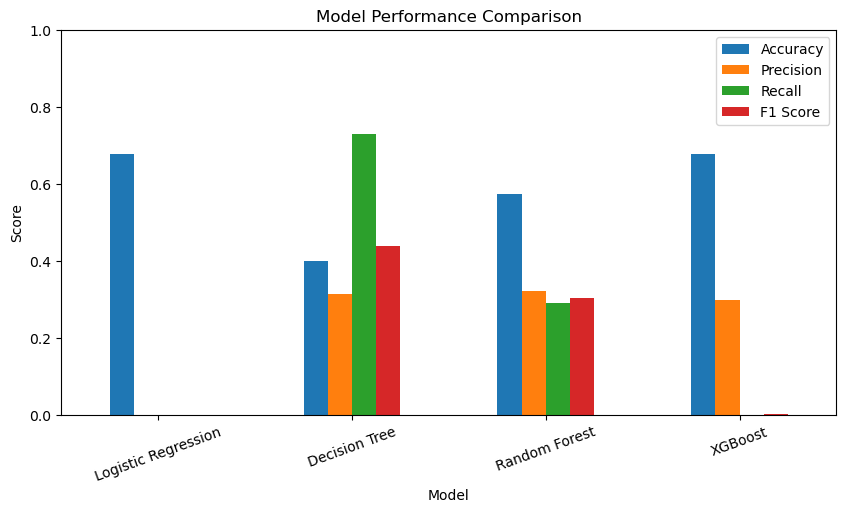

In [24]:
#  Model comparison graph
results.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()


In [25]:
#  Choose the best model using F1 Score
best_index = results["F1 Score"].idxmax()
best_model_name = results.loc[best_index, "Model"]

print("Best Model:", best_model_name)


Best Model: Decision Tree


In [26]:
#  Select the best model
model_list = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "XGBoost": xgb
}

best_model = model_list[best_model_name]
print("Best model selected:", best_model_name)


Best model selected: Decision Tree


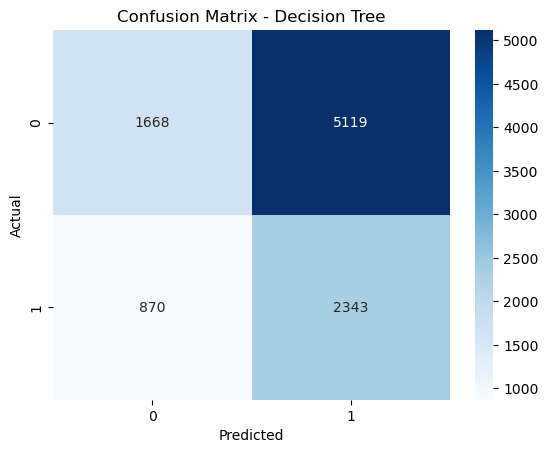

              precision    recall  f1-score   support

           0       0.66      0.25      0.36      6787
           1       0.31      0.73      0.44      3213

    accuracy                           0.40     10000
   macro avg       0.49      0.49      0.40     10000
weighted avg       0.55      0.40      0.38     10000



In [27]:
#  Confusion Matrix for the best model

best_predictions = best_model.predict(
    X_test_scaled if best_model_name == "Logistic Regression" else X_test
)

cm = confusion_matrix(y_test, best_predictions)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix - " + best_model_name)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test, best_predictions, zero_division=0))


In [28]:
#  Fraud probability / Risk Score

if best_model_name == "Logistic Regression":
    probabilities = best_model.predict_proba(X_test_scaled)[:, 1]
else:
    probabilities = best_model.predict_proba(X_test)[:, 1]

risk_score = probabilities * 100

prediction_data = X_test.copy()

prediction_data["Actual_Fraud"] = y_test.values
prediction_data["Fraud_Probability"] = probabilities
prediction_data["Risk_Score"] = risk_score

def risk_category(score):
    if score >= 80:
        return "High Risk"
    elif score >= 50:
        return "Medium Risk"
    else:
        return "Low Risk"

prediction_data["Risk_Category"] = [
    risk_category(x) for x in risk_score
]

prediction_data.head()


,Transaction_Amount,Transaction_Type,Account_Balance,Device_Type,Location,Merchant_Category,Previous_Fraudulent_Activity,Daily_Transaction_Count,Card_Type,Card_Age,...,Day,DayOfWeek,IsWeekend,Amount_Balance_Ratio,High_Amount_Flag,High_Transaction_Frequency,Actual_Fraud,Fraud_Probability,Risk_Score,Risk_Category
12508,133.71,1,5464.13,2,1,1,0,11,3,91,...,2,4,0,0.024466,1,1,0,0.506828,50.682814,Medium Risk
14150,27.06,3,33723.46,0,1,0,0,11,0,158,...,2,3,0,0.000802,0,1,0,0.454911,45.491064,Low Risk
41625,32.60,1,65511.01,2,4,4,0,1,0,143,...,12,5,1,0.000498,0,0,0,0.751056,75.105551,Medium Risk
1991,364.34,2,87825.46,1,0,3,0,12,2,49,...,9,3,0,0.004148,1,1,0,0.506828,50.682814,Medium Risk
7320,240.65,2,5283.10,0,2,4,0,8,3,202,...,25,6,1,0.045542,1,1,0,0.513909,51.390857,Medium Risk


In [29]:
# 28. High-risk transaction count

high_risk = prediction_data[
    prediction_data["Risk_Category"] == "High Risk"
]

print("High Risk Transactions:", len(high_risk))
high_risk.head(10)


High Risk Transactions: 142


,Transaction_Amount,Transaction_Type,Account_Balance,Device_Type,Location,Merchant_Category,Previous_Fraudulent_Activity,Daily_Transaction_Count,Card_Type,Card_Age,...,Day,DayOfWeek,IsWeekend,Amount_Balance_Ratio,High_Amount_Flag,High_Transaction_Frequency,Actual_Fraud,Fraud_Probability,Risk_Score,Risk_Category
26001,1.79,1,82299.26,0,4,1,0,10,1,208,...,3,4,0,0.000022,0,1,0,0.843154,84.315383,High Risk
31532,10.70,0,81365.03,0,1,0,0,1,3,180,...,11,5,1,0.000132,0,0,0,0.958730,95.872985,High Risk
19060,8.79,3,74727.90,0,4,1,0,1,3,141,...,21,5,1,0.000118,0,0,1,0.880833,88.083252,High Risk
42100,77.10,2,94666.38,1,3,4,0,5,2,228,...,31,6,1,0.000814,1,0,0,1.000000,100.000000,High Risk
29876,177.10,0,85908.68,0,1,1,0,9,1,237,...,23,0,0,0.002061,1,1,0,0.964856,96.485597,High Risk
47414,0.67,0,66391.01,1,0,2,0,7,0,37,...,3,1,0,0.000010,0,0,1,1.000000,100.000000,High Risk
23642,105.23,3,12663.48,1,1,0,0,10,0,188,...,13,2,0,0.008309,1,1,0,1.000000,100.000000,High Risk
3962,6.97,0,75466.49,0,1,3,1,2,3,52,...,11,2,0,0.000092,0,0,1,1.000000,100.000000,High Risk
25025,1.06,1,76283.68,1,3,1,0,2,3,39,...,5,1,0,0.000014,0,0,0,1.000000,100.000000,High Risk
27265,5.11,3,83689.04,0,4,1,0,9,0,171,...,7,3,0,0.000061,0,1,1,0.843154,84.315383,High Risk


In [30]:
# 29. Save dashboard-ready data

prediction_data.to_csv(
    "fraud_dashboard_data.csv",
    index=False
)

print("fraud_dashboard_data.csv created")


fraud_dashboard_data.csv created


In [31]:
import os
os.getcwd()

'C:\\Users\\Admin'

In [32]:
# 30. Save the trained model

joblib.dump(best_model, "fraud_detection_model.pkl")
joblib.dump(scaler, "fraud_scaler.pkl")
joblib.dump(label_encoders, "label_encoders.pkl")

print("Model files saved successfully")


Model files saved successfully


In [33]:
# 31. SQLite ETL

import sqlite3

conn = sqlite3.connect("fraud_detection.db")

df.to_sql(
    "transactions",
    conn,
    if_exists="replace",
    index=False
)

prediction_data.to_sql(
    "fraud_predictions",
    conn,
    if_exists="replace",
    index=False
)

conn.close()

print("SQLite ETL completed")


SQLite ETL completed


In [34]:
# 32. Check SQLite database

conn = sqlite3.connect("fraud_detection.db")

check = pd.read_sql(
    "SELECT * FROM transactions LIMIT 10",
    conn
)

conn.close()

check


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Account_Balance,Device_Type,Location,Merchant_Category,Previous_Fraudulent_Activity,Daily_Transaction_Count,...,Card_Age,Fraud_Label,Year,Month,Day,DayOfWeek,IsWeekend,Amount_Balance_Ratio,High_Amount_Flag,High_Transaction_Frequency
0,TXN_33553,USER_1834,39.79,POS,93213.17,Laptop,Sydney,Travel,0,7,...,65,0,2023,8,14,0,0,0.000427,0,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,75725.25,Mobile,New York,Clothing,0,13,...,186,1,2023,6,7,2,0,0.000016,0,1
2,TXN_199,USER_2734,28.96,Online,1588.96,Tablet,Mumbai,Restaurants,0,14,...,226,1,2023,6,20,1,0,0.018214,0,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,76807.20,Tablet,New York,Clothing,0,8,...,76,1,2023,12,7,3,0,0.003311,1,1
4,TXN_39489,USER_2014,31.28,POS,92354.66,Mobile,Mumbai,Electronics,1,14,...,140,1,2023,11,11,5,1,0.000339,0,1
5,TXN_42724,USER_6852,168.55,Online,33236.94,Laptop,Tokyo,Restaurants,0,3,...,51,0,2023,6,5,0,0,0.005071,1,0
6,TXN_10822,USER_5052,3.79,POS,86834.18,Tablet,London,Restaurants,0,2,...,168,0,2023,11,7,1,0,0.000044,0,0
7,TXN_49498,USER_4660,7.08,ATM Withdrawal,45826.27,Tablet,London,Restaurants,0,3,...,182,1,2023,2,25,5,1,0.000154,0,0
8,TXN_4144,USER_1584,34.25,ATM Withdrawal,94392.35,Tablet,Tokyo,Clothing,0,7,...,24,0,2023,3,9,3,0,0.000363,0,0
9,TXN_36958,USER_9498,16.24,POS,91859.97,Mobile,Mumbai,Travel,0,6,...,124,0,2023,9,20,2,0,0.000177,0,0


In [35]:
# 33. Simple fraud alert function

def fraud_alert(score):
    if score >= 80:
        print("🚨 ALERT: High Risk / Possible Fraud Transaction")
    elif score >= 50:
        print("⚠️ WARNING: Medium Risk Transaction")
    else:
        print("✅ Low Risk Transaction")

fraud_alert(50)


⚠️ WARNING: Medium Risk Transaction
